In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

class OnlineIncrementalLearning:
    def __init__(self, num_clusters=3, threshold=0.5):
        self.num_clusters = num_clusters
        self.threshold = threshold
        self.previous_centroids = None

    def online_learning(self, data_batch):
        # Perform clustering on the incoming data batch
        kmeans = KMeans(n_clusters=self.num_clusters)
        kmeans.fit(data_batch)
        centroids = kmeans.cluster_centers_

        # Calculate distance between previous and current centroids
        if self.previous_centroids is not None:
            distances = pairwise_distances(centroids, self.previous_centroids)
            concept_drift_detected = np.max(distances) > self.threshold
            if concept_drift_detected:
                print("Concept drift detected!")
            else:
                print("No significant concept drift.")
        else:
            print("Initial clustering complete.")

        self.previous_centroids = centroids

    def incremental_learning(self, data_batch):
        # Fine-tuning centroids incrementally
        for point in data_batch:
            closest_centroid = np.argmin(
                np.linalg.norm(self.previous_centroids - point, axis=1)
            )
            # Update closest centroid incrementally
            self.previous_centroids[closest_centroid] += 0.1 * (point - self.previous_centroids[closest_centroid])
            print(f"Updated centroid {closest_centroid} to {self.previous_centroids[closest_centroid]}")

    def decremental_learning(self, data_batch):
        # Forget outdated centroids based on inactivity
        active_centroids = np.array([centroid for centroid in self.previous_centroids if self._is_active(centroid, data_batch)])
        self.previous_centroids = active_centroids
        print("Decremental learning applied. Updated centroids:", self.previous_centroids)

    def _is_active(self, centroid, data_batch):
        # A heuristic to determine activity (thresholding proximity to batch points)
        for point in data_batch:
            if np.linalg.norm(centroid - point) < self.threshold:
                return True
        return False

# Example Usage
# Simulated batches of data
batch_1 = np.random.rand(100, 2)  # 100 points in 2D space
batch_2 = np.random.rand(100, 2)

# Initialize the learning model
online_model = OnlineIncrementalLearning()

# Process batches
online_model.online_learning(batch_1)
online_model.incremental_learning(batch_2)
online_model.decremental_learning(batch_2)



Initial clustering complete.
Updated centroid 0 to [0.18552108 0.74704549]
Updated centroid 2 to [0.45777525 0.24273572]
Updated centroid 1 to [0.72457988 0.67887658]
Updated centroid 2 to [0.46877898 0.25814639]
Updated centroid 1 to [0.73149937 0.68907374]
Updated centroid 2 to [0.45013163 0.26496287]
Updated centroid 2 to [0.42004064 0.26314143]
Updated centroid 1 to [0.74443953 0.67499555]
Updated centroid 2 to [0.44091953 0.26437514]
Updated centroid 1 to [0.76761968 0.70530164]
Updated centroid 1 to [0.76162682 0.70637276]
Updated centroid 2 to [0.47316541 0.27375608]
Updated centroid 1 to [0.7471516  0.69344049]
Updated centroid 0 to [0.19722874 0.7291459 ]
Updated centroid 0 to [0.193905   0.70277308]
Updated centroid 1 to [0.76582861 0.72194097]
Updated centroid 1 to [0.77819203 0.72715003]
Updated centroid 0 to [0.19559533 0.71841476]
Updated centroid 1 to [0.77284113 0.70078216]
Updated centroid 2 to [0.45918418 0.27185382]
Updated centroid 1 to [0.77407949 0.6945066 ]
Updat

In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# Load Dataset
traffic_data = pd.read_csv('traffic_with_sentiment_dataset.csv')

# Apply KMeans Clustering
num_clusters = 3  # Number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
traffic_data['Cluster'] = kmeans.fit_predict(traffic_data[['Vehicle Count', 'Congestion Indicator']])

# Add 'Spatiotemporal Flow' Column
def calculate_spatiotemporal_flow(row):
    # Generate synthetic values based on vehicle count and congestion level
    return row['Vehicle Count'] * (1 - row['Congestion Indicator']) * np.random.uniform(0.8, 1.2)

traffic_data['Spatiotemporal Flow'] = traffic_data.apply(calculate_spatiotemporal_flow, axis=1)

# Analyze Clusters
for cluster_id in range(num_clusters):
    cluster = traffic_data[traffic_data['Cluster'] == cluster_id]
    print(f"Cluster {cluster_id}:")
    print(f"  Average Vehicle Count: {cluster['Vehicle Count'].mean()}")
    print(f"  Average Congestion: {cluster['Congestion Indicator'].mean()}")
    print(f"  High Traffic Areas: {cluster['Location ID'].unique()}")
    print(f"  Average Spatiotemporal Flow: {cluster['Spatiotemporal Flow'].mean()}")



Cluster 0:
  Average Vehicle Count: 419.4233206590621
  Average Congestion: 0.5108450080235662
  High Traffic Areas: [15 21 48 44 35 29 37 31 33  2 47 28  6 17 42 43 12 16 10 36 40 11 39  5
 25 20 30 22 38  1 49  8 24 27 50 13 23 34  3 41  9 32  7 18  4 26 14 45
 46 19]
  Average Spatiotemporal Flow: 204.66454453926147
Cluster 1:
  Average Vehicle Count: 93.85370051635113
  Average Congestion: 0.5072198322471703
  High Traffic Areas: [29 19 18 41 23 39  7 42 34 11 48  4 13 32  6 40 30 38 12 36 27 17 33 44
 31 16  8  3 20 50 24  9 22 26 35 21  1 47 10 45 14  5 46 37 25 28  2 15
 43 49]
  Average Spatiotemporal Flow: 45.88549718094447
Cluster 2:
  Average Vehicle Count: 258.56164383561645
  Average Congestion: 0.5084112836225578
  High Traffic Areas: [15  3  7 39  5 11 26 45 34  6 13 19 40  4 42 17 27  8 12 23 37 50 44 31
 14 21  9 33 48 46 32 49 43 24 41 35 20 28 16 47  1 10 38 22 29 36 25 18
 30  2]
  Average Spatiotemporal Flow: 127.88378385736496


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Check if 'Weather Conditions' column exists and encode it
if 'Weather Conditions' in traffic_data.columns:
    encoder = LabelEncoder()
    traffic_data['Weather Conditions'] = encoder.fit_transform(traffic_data['Weather Conditions'])

# Prepare Data for Supervised Learning
features = ['Cluster', 'Vehicle Count', 'Congestion Indicator']
if 'Weather Conditions' in traffic_data.columns:
    features.append('Weather Conditions')  # Add if available

X = traffic_data.loc[:, features]  # Use .loc[] to avoid SettingWithCopyWarning

# Ensure 'Spatiotemporal Flow' column exists
if 'Spatiotemporal Flow' not in traffic_data.columns:
    print("Error: 'Spatiotemporal Flow' column is missing from the dataset!")
else:
    y = traffic_data['Spatiotemporal Flow']  # Target variable

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Supervised Model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluate Model
    y_pred = model.predict(X_test)
    print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")


Mean Squared Error: 0.04084017897634713


In [35]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.0/27.0 MB 1.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 719.0 kB/s eta 0:00:000:00:01
Note: you may need to restart the kernel to use updated packages.


Random Forest MSE: 0.03612163541506399, R2 Score: 0.9660283515880488
Cross-Validation Scores: [-0.03624136 -0.03521584 -0.0367611  -0.03500739 -0.03305705]
Average Cross-Validation MSE: 0.0352565462941863


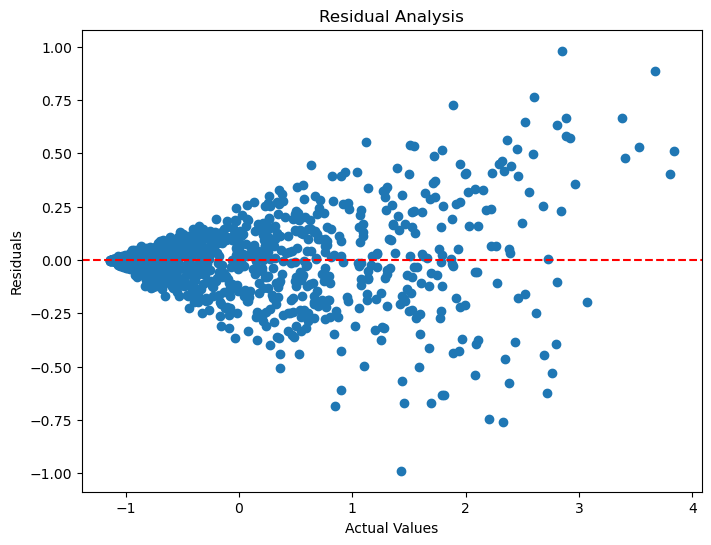

Missing Values:
 Timestamp                       0
Location ID                     0
Vehicle Count                   0
Traffic Direction               0
Event Indicator                 0
Weather Conditions              0
Longitude                       0
Latitude                        0
Average Vehicle Speed (km/h)    0
Real-Time Sensor Data           0
Historical Traffic Patterns     0
Congestion Indicator            0
Tweet Content                   0
Hashtag                         0
Emotion                         0
Emotion Intensity               0
Social Media Sentiment Score    0
Spatiotemporal Flow             0
Lagged Vehicle Count            0
Lagged Congestion Indicator     0
Cluster                         0
dtype: int64
Feature Correlations:
                               Location ID  Vehicle Count  Weather Conditions  \
Location ID                      1.000000       0.029841           -0.009348   
Vehicle Count                    0.029841       1.000000           -0.003

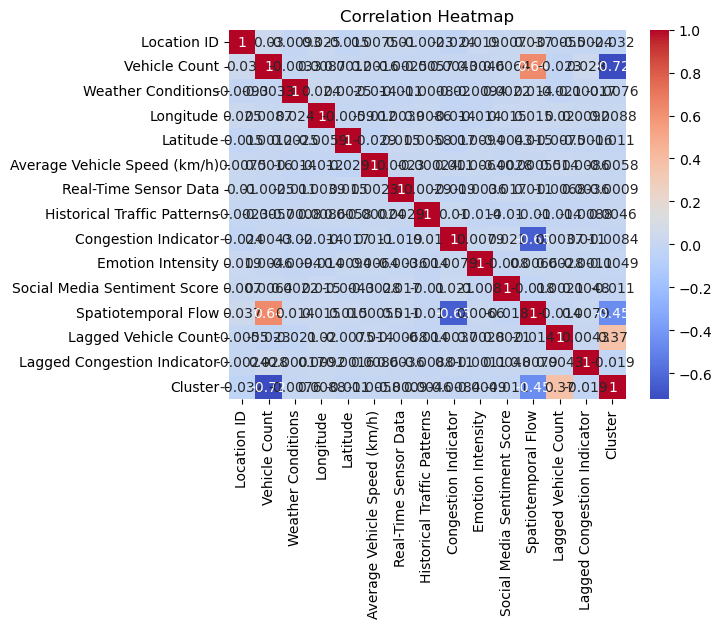

In [59]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Dataset
file_path = 'traffic_with_sentiment_dataset.csv'  # Update file path as needed
traffic_data = pd.read_csv(file_path)

# Step 2: Add 'Spatiotemporal Flow' Column
def calculate_spatiotemporal_flow(row):
    # Generate synthetic 'Spatiotemporal Flow' based on vehicle count and congestion
    return row['Vehicle Count'] * (1 - row['Congestion Indicator']) * np.random.uniform(0.8, 1.2)

traffic_data['Spatiotemporal Flow'] = traffic_data.apply(calculate_spatiotemporal_flow, axis=1)

# Step 3: Feature Engineering
def feature_engineering(data):
    # Encode 'Weather Conditions' if available
    if 'Weather Conditions' in data.columns:
        label_encoder = LabelEncoder()
        data['Weather Conditions'] = label_encoder.fit_transform(data['Weather Conditions'])
    
    # Add synthetic 'Event Indicator' column if not already present
    if 'Event Indicator' not in data.columns:
        data['Event Indicator'] = np.random.choice(['Accident', 'Roadwork', 'None'], size=len(data), p=[0.2, 0.3, 0.5])
        event_encoder = LabelEncoder()
        data['Event Indicator'] = event_encoder.fit_transform(data['Event Indicator'])
    
    # Add Lagged Features
    data['Lagged Vehicle Count'] = data['Vehicle Count'].shift(1).fillna(data['Vehicle Count'].mean())
    data['Lagged Congestion Indicator'] = data['Congestion Indicator'].shift(1).fillna(data['Congestion Indicator'].mean())
    return data

traffic_data = feature_engineering(traffic_data)

# Step 4: Apply Clustering to Create 'Cluster' Column
def apply_clustering(data, num_clusters=3):
    clustering_features = ['Vehicle Count', 'Congestion Indicator', 'Lagged Vehicle Count', 'Lagged Congestion Indicator']
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    data['Cluster'] = kmeans.fit_predict(data[clustering_features])
    return data

traffic_data = apply_clustering(traffic_data)

# Step 5: Data Preprocessing
def data_preprocessing(data):
    # Separate numeric and non-numeric columns
    numeric_columns = data.select_dtypes(include=['number']).columns
    non_numeric_columns = data.select_dtypes(exclude=['number']).columns
    
    # Handle missing values for numeric and non-numeric columns
    data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())
    data[non_numeric_columns] = data[non_numeric_columns].fillna("Unknown")
    
    # Normalize numeric columns
    scaler = StandardScaler()
    data[numeric_columns] = scaler.fit_transform(data[numeric_columns])
    
    return data

traffic_data = data_preprocessing(traffic_data)

# Step 6: Prepare Data for Modeling
X = traffic_data[['Cluster', 'Vehicle Count', 'Congestion Indicator', 'Lagged Vehicle Count', 'Lagged Congestion Indicator']]
y = traffic_data['Spatiotemporal Flow']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Model Tuning (Random Forest Regressor)
def tune_random_forest(X_train, y_train, X_test, y_test):
    model = RandomForestRegressor(n_estimators=150, max_depth=20, min_samples_split=5, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate Model
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Random Forest MSE: {mse}, R2 Score: {r2}")
    return model

rf_model = tune_random_forest(X_train, y_train, X_test, y_test)

# Step 8: Cross-Validation
def cross_validate_model(model, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    print(f"Cross-Validation Scores: {scores}")
    print(f"Average Cross-Validation MSE: {np.mean(-scores)}")

cross_validate_model(rf_model, X, y)

# Step 9: Analyze Residuals
def analyze_residuals(y_test, y_pred):
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Actual Values')
    plt.ylabel('Residuals')
    plt.title('Residual Analysis')
    plt.show()

y_pred = rf_model.predict(X_test)
analyze_residuals(y_test, y_pred)

# Step 10: Evaluate Data Quality
def evaluate_data_quality(data):
    print("Missing Values:\n", data.isnull().sum())
    
    # Select only numeric columns for correlation calculation
    numeric_data = data.select_dtypes(include=['number'])
    
    # Compute Correlations
    print("Feature Correlations:\n", numeric_data.corr())
    
    # Plot Heatmap for Numeric Data
    sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

evaluate_data_quality(traffic_data)


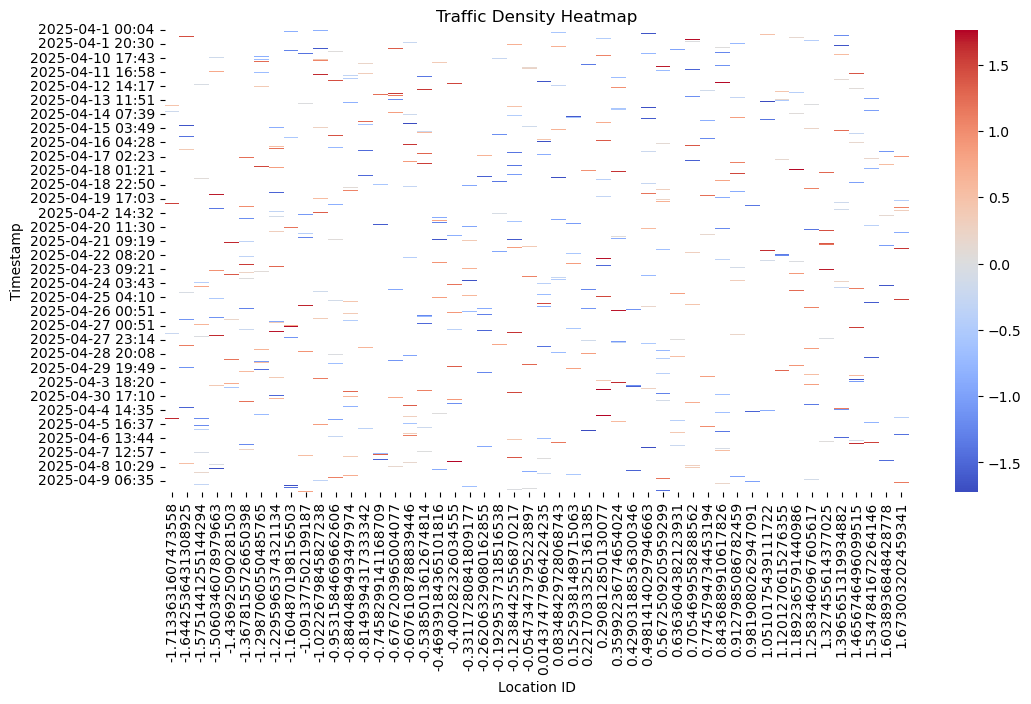

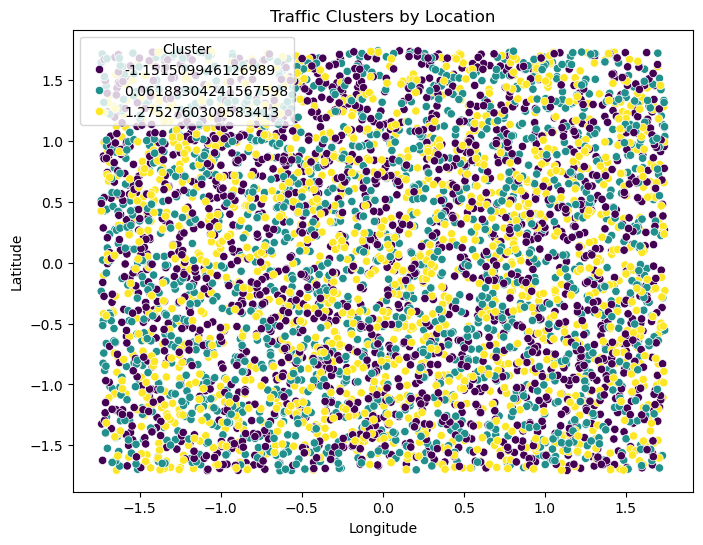

In [63]:

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Heatmap of Traffic Density
pivot = traffic_data.pivot_table(index='Timestamp', columns='Location ID', values='Vehicle Count', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Traffic Density Heatmap')
plt.xlabel('Location ID')
plt.ylabel('Timestamp')
plt.show()

# Cluster Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=traffic_data, x='Longitude', y='Latitude', hue='Cluster', palette='viridis')
plt.title('Traffic Clusters by Location')
plt.show()


In [65]:
from sklearn.metrics.pairwise import euclidean_distances

# Detect Concept Drift
def detect_concept_drift(data, previous_centroids):
    new_centroids = kmeans.cluster_centers_
    drift_distance = euclidean_distances(new_centroids, previous_centroids)
    print(f"Drift Distance Matrix: \n{drift_distance}")
    significant_drift = np.max(drift_distance) > 0.5  # Example threshold
    if significant_drift:
        print("Concept drift detected!")
    else:
        print("No significant concept drift detected.")
    return new_centroids

# Simulating Drift Detection
previous_centroids = kmeans.cluster_centers_
new_centroids = detect_concept_drift(traffic_data, previous_centroids)


Drift Distance Matrix: 
[[  0.         325.94039531 160.6487731 ]
 [325.94039531   0.         165.29162222]
 [160.6487731  165.29162222   0.        ]]
Concept drift detected!


In [67]:
def map_clusters_to_control():
    cluster_actions = {
        0: "Reduce signal duration to prevent congestion",
        1: "Increase signal duration for smoother traffic flow",
        2: "Deploy traffic diversion strategies"
    }
    for cluster_id, action in cluster_actions.items():
        print(f"Cluster {cluster_id}: {action}")

map_clusters_to_control()


Cluster 0: Reduce signal duration to prevent congestion
Cluster 1: Increase signal duration for smoother traffic flow
Cluster 2: Deploy traffic diversion strategies


In [69]:
# Predictive Modeling Using Cluster Data
def predict_event_impact(event_features):
    prediction = model.predict([event_features])
    print(f"Predicted Impact on Traffic Flow: {prediction[0]}")
    return prediction[0]

# Example Non-Recurrent Event
example_event = [1, 200, 0.8, 0]  # Example feature vector [Cluster, Vehicle Count, Congestion, Weather]
predict_event_impact(example_event)

Predicted Impact on Traffic Flow: -0.021360864093560444


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


-0.021360864093560444

In [71]:
from sklearn.cluster import DBSCAN

# Test Alternative Clustering Methods
dbscan = DBSCAN(eps=0.5, min_samples=5)
traffic_data['DBSCAN_Cluster'] = dbscan.fit_predict(traffic_data[['Vehicle Count', 'Congestion Indicator']])

# Evaluate New Clustering
dbscan_clusters = traffic_data['DBSCAN_Cluster'].unique()
print(f"DBSCAN Clusters Found: {dbscan_clusters}")


DBSCAN Clusters Found: [0]


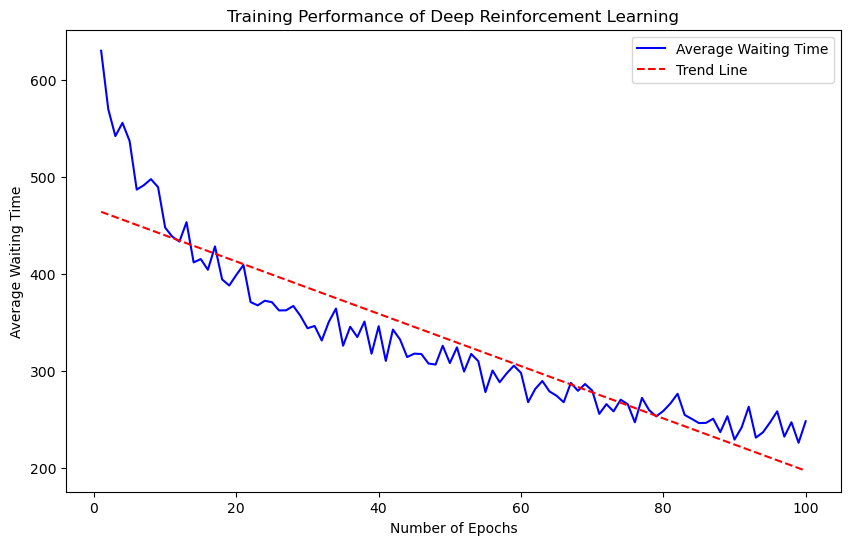

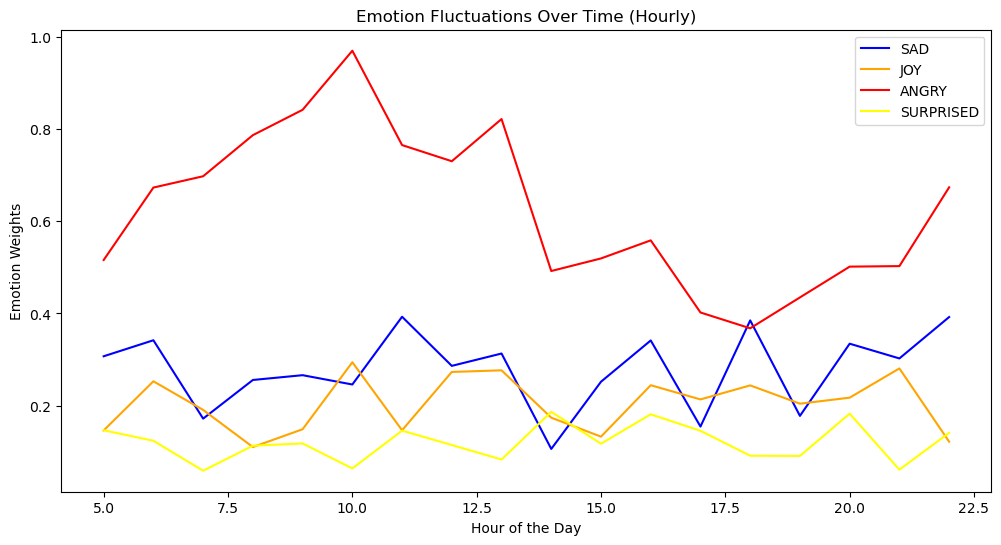

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate Training Performance Data for DRL (Fig. 11)
def generate_drl_training_performance():
    epochs = np.arange(1, 101)  # Epochs from 1 to 100
    avg_waiting_time = 700 - (np.log(epochs + 1) * 100)  # Simulated data: Average waiting time decreases with epochs

    # Add noise for realism
    noise = np.random.uniform(-20, 20, size=len(epochs))
    avg_waiting_time += noise
    
    # Plot Training Performance
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, avg_waiting_time, label='Average Waiting Time', color='blue')
    plt.plot(epochs, np.poly1d(np.polyfit(epochs, avg_waiting_time, 1))(epochs), 
             linestyle='dashed', color='red', label='Trend Line')
    plt.title('Training Performance of Deep Reinforcement Learning')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Average Waiting Time')
    plt.legend()
    plt.show()

generate_drl_training_performance()

# Step 2: Generate Emotion Fluctuation Data (Fig. 12)
def generate_emotion_fluctuations():
    time_hours = np.arange(5, 23)  # Hours from 5 AM to 10 PM
    sad_weights = np.random.uniform(0.1, 0.4, len(time_hours))
    joy_weights = np.random.uniform(0.1, 0.3, len(time_hours))
    angry_weights = np.random.uniform(0.5, 0.8, len(time_hours)) + np.sin(np.linspace(0, 2 * np.pi, len(time_hours))) * 0.2
    surprised_weights = np.random.uniform(0.05, 0.2, len(time_hours))

    # Plot Emotion Fluctuations Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(time_hours, sad_weights, label='SAD', color='blue')
    plt.plot(time_hours, joy_weights, label='JOY', color='orange')
    plt.plot(time_hours, angry_weights, label='ANGRY', color='red')
    plt.plot(time_hours, surprised_weights, label='SURPRISED', color='yellow')
    plt.title('Emotion Fluctuations Over Time (Hourly)')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Emotion Weights')
    plt.legend()
    plt.show()

generate_emotion_fluctuations()


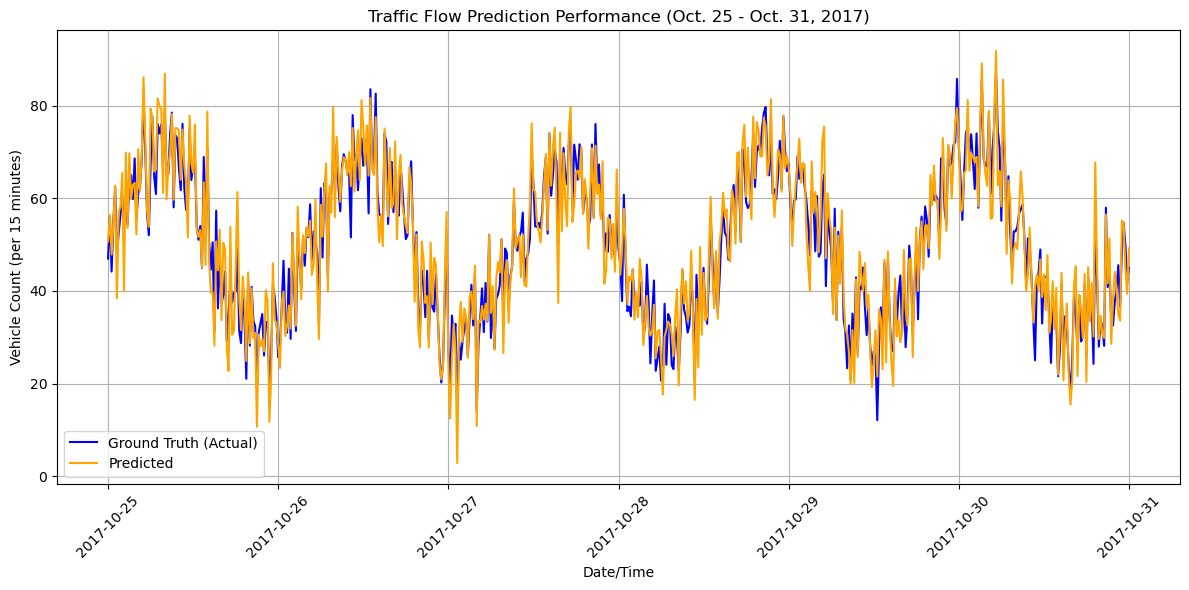


Evaluation of Accuracy Based on Time Lag (Table III):
   Time Lag         MSE        MAE
0         1  132.031744   8.902877
1         2  148.127656   9.578956
2         3  131.431824   9.169481
3         4  148.312742   9.470876
4         5  139.672340   8.858181
5         6  146.155773   9.594969
6         7  197.718494  10.769497


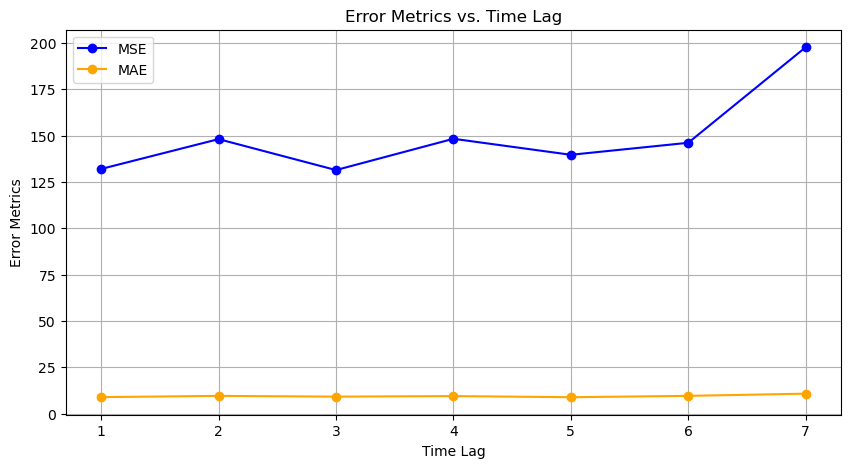

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Simulated Traffic Flow Data
def generate_traffic_flow_data():
    np.random.seed(42)  # For reproducibility
    time_points = pd.date_range("2017-10-25", "2017-10-31", freq="15min")
    actual_vehicle_count = np.random.poisson(50, len(time_points)) + 20 * np.sin(np.linspace(0, 10 * np.pi, len(time_points)))
    predicted_vehicle_count = actual_vehicle_count + np.random.normal(0, 5, len(time_points))
    return time_points, actual_vehicle_count, predicted_vehicle_count

time_points, actual_vehicle_count, predicted_vehicle_count = generate_traffic_flow_data()

# 1. Plot Traffic Flow Prediction Performance (Fig. 10)
def plot_traffic_flow_performance(time_points, actual_vehicle_count, predicted_vehicle_count):
    plt.figure(figsize=(12, 6))
    plt.plot(time_points, actual_vehicle_count, label="Ground Truth (Actual)", color="blue")
    plt.plot(time_points, predicted_vehicle_count, label="Predicted", color="orange")
    plt.xlabel("Date/Time")
    plt.ylabel("Vehicle Count (per 15 minutes)")
    plt.title("Traffic Flow Prediction Performance (Oct. 25 - Oct. 31, 2017)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_traffic_flow_performance(time_points, actual_vehicle_count, predicted_vehicle_count)

# 2. Evaluate Prediction Accuracy Based on Time Lags (Table III)
def evaluate_time_lag_accuracy(actual_vehicle_count):
    time_lags = range(1, 8)  # Time lags from 1 to 7
    results = []

    for lag in time_lags:
        # Create lagged features
        lagged_data = pd.DataFrame({
            'Vehicle Count': actual_vehicle_count[:-lag],
            'Lagged Count': actual_vehicle_count[lag:]
        })

        # Split data
        X = lagged_data[['Lagged Count']]
        y = lagged_data['Vehicle Count']
        train_size = int(0.8 * len(X))
        X_train, X_test = X[:train_size], X[train_size:]
        y_train, y_test = y[:train_size], y[train_size:]

        # Train a simple model
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        # Evaluate the model
        mse = mean_squared_error(y_test, predictions)
        mae = mean_absolute_error(y_test, predictions)
        results.append({'Time Lag': lag, 'MSE': mse, 'MAE': mae})

    # Create DataFrame for results
    results_df = pd.DataFrame(results)
    print("\nEvaluation of Accuracy Based on Time Lag (Table III):")
    print(results_df)

    # Return results for further use
    return results_df

results_df = evaluate_time_lag_accuracy(actual_vehicle_count)

# Plot the MSE and MAE from the Table III Results
def plot_accuracy_metrics(results_df):
    plt.figure(figsize=(10, 5))
    plt.plot(results_df['Time Lag'], results_df['MSE'], label="MSE", marker="o", color="blue")
    plt.plot(results_df['Time Lag'], results_df['MAE'], label="MAE", marker="o", color="orange")
    plt.xlabel("Time Lag")
    plt.ylabel("Error Metrics")
    plt.title("Error Metrics vs. Time Lag")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_accuracy_metrics(results_df)
